In [14]:
import pandas as pd

In [6]:
df = pd.read_csv ("netflix_titles.csv")

In [7]:
df.shape

(8807, 12)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [9]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [26]:
# Fill multiple columns at once
df = df.fillna({
    "director": "Unknown",
    "country": "Unknown",
    "cast": "Unknown"
})

# Fill rating with mode
df["rating"] = df["rating"].fillna(df["rating"].mode()[0])

# Drop missing values
df = df.dropna(subset=["date_added", "duration"])

In [12]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [ ]:
#Visualisation 

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

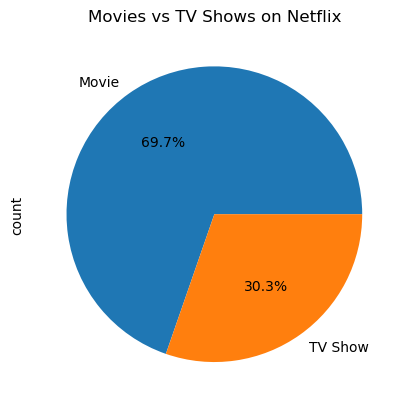

In [17]:
df["type"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Movies vs TV Shows on Netflix")
plt.show()

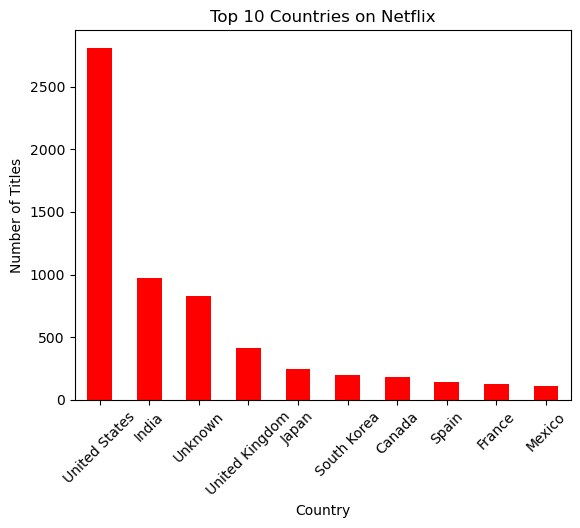

In [18]:
df["country"].value_counts().head(10).plot(kind="bar", color="red")
plt.title("Top 10 Countries on Netflix")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)   
plt.show()

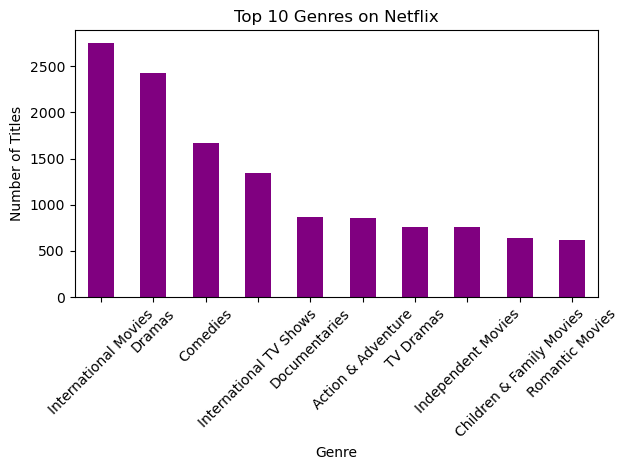

In [19]:
df["listed_in"].str.split(",").explode().str.strip().value_counts().head(10).plot(kind="bar", color="purple")
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.tight_layout()  
plt.show()

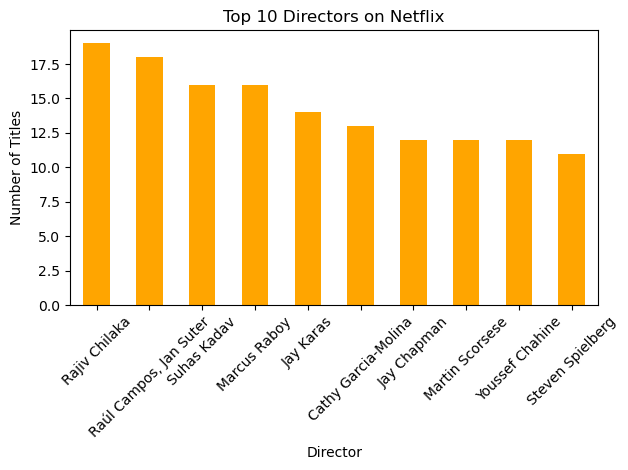

In [24]:
df[df["director"] != "Unknown"]["director"].value_counts().head(10).plot(kind="bar", color="orange")
plt.title("Top 10 Directors on Netflix")
plt.xlabel("Director")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()